# PyEMMO-Pyleecan Tutorial
This is a tutorial on how to create or load a Pyleecan machine and translate it to ONELAB using the PyEMMO pyleecan-api.

This tutorial has the following sections:
1. Load or create a Pyleecan machine and how to modifiy its properties
2. How to use use the PyEMMO pyleecan-api to create a ONELAB model
3. How to run a simple simulation in ONELAB 

## 1. Load or create a Pyleecan machine and how to modifiy its properties

Pyleecan has a lot of useful tutorials under [Pyleecan tutorials][pylcn_tutorials].
See those for futher details on how to use the pyleecan motor toolbox. 

There are two ways to get a Pyleecan machine:

- Load a existing machine using the `load` function.
- Create a machine with a python script by using the Pyleecan classes.
  See the [`01_tuto_Machine.ipynb`][pylcn_tutorial_machine] tutorial for that.


You can load an existing Pyleecan model using:

[pylcn_tutorials]: https://pyleecan.org/tutorials.html
[pylcn_tutorial_machine]: https://pyleecan.org/01_tuto_Machine.html

In [1]:
# Tell matlab to use the inline kernel to show the figures in the notebook:
%matplotlib inline

# Load the machine
from os.path import join
from pyleecan.Functions.load import load
from pyleecan.definitions import DATA_DIR

IPMSM_A = load(join(DATA_DIR, "Machine", "Toyota_Prius.json"))
# In Jupyter notebook, we set is_show_fig=False to skip call to fig.show() to avoid a warning message
# All plot methods return the corresponding matplotlib figure and axis to further edit the resulting plot
fig, ax = IPMSM_A.plot(is_show_fig=False)

This can be a default machine from the Pyleecan `DATA` directory or you can create your own machine using the Pyleecan GUI.
See [Pyleecan Webinar on how to use the GUI][GUI_webinar] or just try it yourself by running:

[GUI_webinar]: https://pyleecan.org/webinar_1.html

In [2]:
# Start Pyleecan GUI from the Jupyter Notebook (this might take a second to start ;) )
# %run -m pyleecan

Now you can modify the machine properties depending on the classes used.
E.g. we can modify the magnets remanence flux density by accessing:

In [3]:
new_Br = 1.19  # Tesla
IPMSM_A.rotor.hole[0].magnet_0.mat_type.mag.Brm20 = new_Br
IPMSM_A.rotor.hole[0].magnet_1.mat_type.mag.Brm20 = new_Br

Or you can modify the geoemtry by changing the respecive parameters.
There parameters can be found in the Pyleecan documentation or for a existing machine by using the method `plot_schematics`.

In [4]:
# print rotor class info
print(f"Rotor parameters can be found in Pyleecan class: {type(IPMSM_A.rotor.hole[0])}")
# use plot_schematics to show parameters
IPMSM_A.rotor.hole[0].plot_schematics(is_default=True, is_show_fig=False)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Rotor parameters can be found in Pyleecan class: <class 'pyleecan.Classes.HoleM50.HoleM50'>


(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='(m)', ylabel='(m)'>)

In [5]:
from matplotlib import pyplot as plt

fig, axes = plt.subplots(1, 2)  # create subplot to show results side by side
# plot inital config
fig, ax = IPMSM_A.rotor.plot(sym=8, fig=fig, ax=axes[0])
_ = ax.set_ylim([-0.01, 0.065])
_ = ax.set_xlim([0.04, 0.08])
_ = ax.set_title(f"H2 = {IPMSM_A.rotor.hole[0].H2*1e3} mm")

# change parameter for magnet-lamination overlap
IPMSM_A.rotor.hole[0].H2 = 3e-3

# plot rotor segment after parameter change
fig, ax = IPMSM_A.rotor.plot(sym=8, fig=fig, ax=axes[1])
_ = ax.set_ylim([-0.01, 0.065])
_ = ax.set_xlim([0.04, 0.08])
_ = ax.set_title(f"H2 = {IPMSM_A.rotor.hole[0].H2*1e3} mm")

But we could also just load the JSON machine file in the Pyleecan GUI and modify the properties there.

## 2. How to use use the PyEMMO pyleecan-api to create a ONELAB model
From here on its very easy to create a ONELAB machine model using the `pyemmo.api.pyleecan` api package.
You simply need to call the `pyemmo.api.pyleecan.main.main` function.
You will need to supply the **Pyleecan machine object** and a **path where the ONELAB model files shoud be stored**.
You can optionally specify if the Gmsh GUI should be opened after the model has been generated.
Additionally the Gmsh and GetDP executables to use for opening the GUI and run a simulation. 

In [6]:
from pyemmo.api.pyleecan import main as pyleecan_api
from pyemmo.definitions import RESULT_DIR

pyemmo_script = pyleecan_api.main(
    pyleecan_machine=IPMSM_A,
    model_dir=join(
        RESULT_DIR, "Toyota_Prius_ONELAB"
    ),  # path were the model files should be stored
    use_gui=False,  # select if you want to open the model in Gmsh.
    gmsh="",  # optional gmsh executable. If use_gui is True, pyemmo will try to find a executable on your computer
    getdp="",  # optional getdp executable. For simulation in the GUI.
)

INFO:root:PyEMMO started on 2025-11-24 17:28:03
INFO:root:PyEMMO API started on 2025-11-24 17:28:05
INFO:root:Starting stator airgap creation since no airgap was given by the input dict.
INFO:root:Starting rotor airgap creation since no airgap was given by the input dict.
INFO:root:Generating the Script object in JSON API.


The created geometry will be saved as a *.geo* file (Gmsh specific file format).
The files used by GetDP to run a simulation will be saved as *.pro* files.
If you now look at the contents of the newly created folder *\Toyota_Prius_ONELAB*, you will find the following model files:

| Model File | Description|
|------------|------------|
| Toyota_Prius.geo | Geometry (CAD) |
| Toyota_Prius.pro | Main Simulation Setup |
| Toyota_Prius_param.geo | Global Machine and Simulation parameters |
| machine_magstadyn_a.pro | Problem Template for Electrical Machines |
| Circuit_SC_ASM.pro | Optional Circuit Definition (for Induction Machines) |
| pyemmo_jsonAPI.log | PyEMMO Model Creation log-file |


## 4. How to run a simple simulation in ONELAB 

After creating a machine model you can start a simulation in the GUI adjusting the parameters and clicking the "Run" botton.
Or you can you the `runCalcforCurrent` function and start a simulation from Python as a subprocess.
Therefore you can specify the same parameters you find in GUI using a parameter dictionary like in the example below.
You can find all adjustable constants and parameters in the documentation under **ONELAB Model Constants** and **ONELAB Model Parameters**.

For PM-machines PyEMMO will try to calculate the dq-System offset between rotor and stator. See **dq-Offset calculation** for more details.

In [ ]:
import os
import time

import numpy as np

from pyemmo.functions.runOnelab import runCalcforCurrent, findGetDP

# Simulation parameters
n = 1500
id = -10
iq = 50
resId = "test_simulation"  # result identifier and result folder name

# create param dict for simulation
paramDict = {
    # model .pro file path
    "pro": pyemmo_script.proFilePath,
    # Gmsh Parameters
    "gmsh": {"exe": r"", "gmsf": 2},
    # GetDP Parameters
    "getdp": {
        "exe": findGetDP(),  # GetDP executable, you can use the function findGetDP
        # which tries to find the exe on you PC.
        # change gmsh and getdp verbosity level (0-99)
        # 0 - fatal, 1 - error, 2 - warning, 3 - info, 5 - debug, 99 - extended debug
        "verbosity level": 3,
        "Flag_Debug": 0,  # epxort debug infos and results from GetDP
        ## Analysis Parameters
        "Flag_AnalysisType": 1,  # 0 - static, 1 - transient
        "Flag_SrcType_Stator": 1,  # 1 - current source, 2 - voltage source (not finally implemented)
        "initrotor_pos": 0.0,  # initial rotor position in °
        "d_theta": 0.5,  # angular step size in °
        "finalrotor_pos": 45,  # final rotor position in °
        # "RPM": n, # rotational speed
        "Flag_EC_Magnets": 0,  # control magnet eddy current calculation
        #
        ## Result settings
        "res": pyemmo_script.resultsPath,  # main results folder
        "ResId": resId,  # current simulation result folder ID
        "Flag_PrintFields": 0,  # control field result output (.pos files, only last timestep)
        "Flag_ClearResults": 1,  # remove results if existing, otherwise existing results will be imported
        #
        ## Excitation parameters
        "ID_RMS": id / np.sqrt(2),
        "IQ_RMS": iq / np.sqrt(2),
    },
    # "log": f"{resId}.log",  # optional: log file name
    "info": "",  # optional: info string to save with simulation config
    "datetime": time.ctime(),  # optional: current time
    "PostOp": [],  # PostOperations to execute after simulation.
    # Standard Option is: GetBOnRadius
}
# run simulation:
results = runCalcforCurrent(paramDict)

INFO:root:Running simulation for result-ID 'test_simulation'
INFO:root:got line from subprocess: b'Info    : Started (Mon Nov 24 18:00:38 2025, Wall = 0s, CPU = 0.015625s, Mem = 17.2773Mb)\n'
INFO:root:got line from subprocess: b'\x1bNumber of poles total (NbrPolesTot) = 8\x1b\n'
INFO:root:got line from subprocess: b'\x1bNumber of poles in Model = 1\x1b\n'
INFO:root:got line from subprocess: b'\x1bSymmetry Faktor = 8\x1b\n'
INFO:root:got line from subprocess: b'\x1bFlag Symmetry = 1\x1b\n'
INFO:root:got line from subprocess: b'\x1bAirgap radius = 0.08050\x1b\n'
INFO:root:got line from subprocess: b'\x1bFlag_Cir = 0\x1b\n'
INFO:root:got line from subprocess: b'\x1bFlag_SrcType_Stator = 1\x1b\n'
INFO:root:got line from subprocess: b'\x1bFlag_ImposedCurrentDensity = 1\x1b\n'
INFO:root:got line from subprocess: b'\x1bRemanence flux density of magnet material MagnetPrius at temperature 20.0 \xc2\xb0C is 1.19000 T\x1b\n'
INFO:root:got line from subprocess: b'\x1bResId is /test_simulation/\x1

After the simulation has finished, pyemmo automatically imports the standard global result values using `pyemmo.functions.import_results.main` function and output the results in a dictionary structure.
Here we store this output in the variable `results`.

Using `print` or `pprint` (pretty-print) we can show the dictionary keys.

Depended on the simulation parameters defined in `param_dict["getdp"]`, not all of the keys must contain result data.

In [ ]:
from pprint import pprint

pprint(results.keys())
pprint(results["flux"].keys())

dict_keys(['current', 'voltage', 'time', 'torque', 'torque_vw', 'rotor torque', 'stator torque', 'flux', 'inducedVoltage', 'rotorPos'])
dict_keys(['a', 'b', 'c', 'd', 'q', '0'])


We can use ``matplotlib.pyplot`` to plot some time depended results:

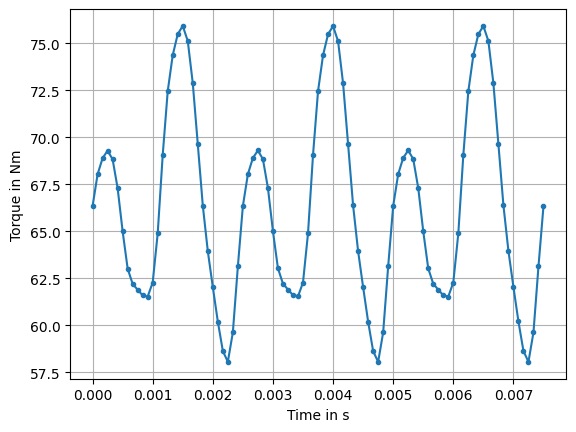

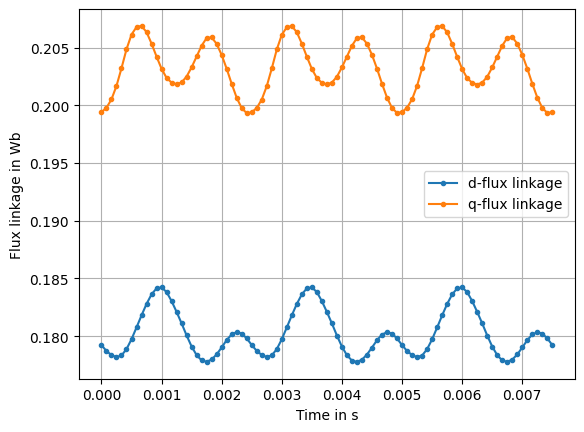

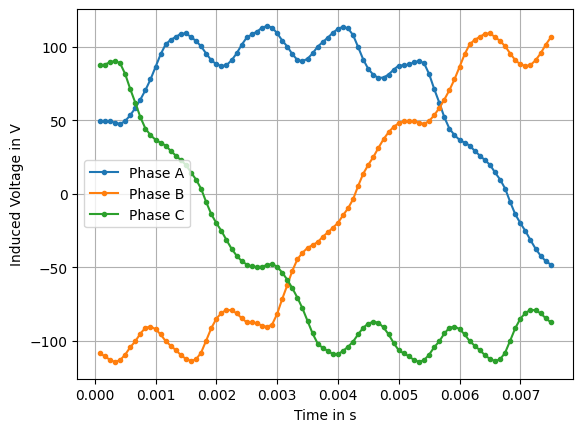

In [57]:
# Plot torque, flux and induced voltage results
%matplotlib inline

fig, ax = plt.subplots()
ax.plot(results["time"], results["torque"], ".-")
ax.set_ylabel("Torque in Nm")
ax.set_xlabel("Time in s")
ax.grid()

fig, ax = plt.subplots()
ax.plot(results["time"], results["flux"]["d"], ".-", label="d-flux linkage")
ax.plot(results["time"], results["flux"]["q"], ".-", label="q-flux linkage")
ax.set_ylabel("Flux linkage in Wb")
ax.set_xlabel("Time in s")
ax.grid()
ax.legend()

fig, ax = plt.subplots()
ax.plot(results["time"][1:], results["inducedVoltage"]["a"], ".-", label="Phase A")
ax.plot(results["time"][1:], results["inducedVoltage"]["b"], ".-", label="Phase B")
ax.plot(results["time"][1:], results["inducedVoltage"]["c"], ".-", label="Phase C")
ax.set_ylabel("Induced Voltage in V")
ax.set_xlabel("Time in s")
ax.grid()
ax.legend()

## 5. What is possible, whats not?

## 6. User-defined results